<a href="https://colab.research.google.com/github/202355202033A2/Tugas2_Deep_Learning/blob/main/TUGAS_2_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [20]:
# 2. DATASET PATH
# ============================================================

DATASET_PATH = "/content/drive/MyDrive/Dataset"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50
SEED = 42

In [21]:
# 3. LOAD DATASET AND CREATE DATAFRAME
# ============================================================

filepaths = []
labels = []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            filepaths.append(file_path)
            labels.append(folder)


In [22]:
import pandas as pd
import os

# Redefine DATASET_PATH for robustness, assuming it's from cell 8d9I3xooJCdn
DATASET_PATH = "/content/drive/MyDrive/Dataset"

filepaths = []
labels = []

for folder in os.listdir(DATASET_PATH):
    folder_path = os.path.join(DATASET_PATH, folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            filepaths.append(file_path)
            labels.append(folder)

# Create DataFrame
df = pd.DataFrame({
    "filepaths": filepaths,
    "labels": labels
})

print("Total Images:", len(df))
print(df.head())

Total Images: 1610
                                           filepaths             labels
0  /content/drive/MyDrive/Dataset/Cassava___healt...  Cassava___healthy
1  /content/drive/MyDrive/Dataset/Cassava___healt...  Cassava___healthy
2  /content/drive/MyDrive/Dataset/Cassava___healt...  Cassava___healthy
3  /content/drive/MyDrive/Dataset/Cassava___healt...  Cassava___healthy
4  /content/drive/MyDrive/Dataset/Cassava___healt...  Cassava___healthy


In [23]:
import os

# List contents of MyDrive to help find the correct path
print("Contents of /content/drive/MyDrive/")
try:
    for item in os.listdir('/content/drive/MyDrive/'):
        print(item)
except FileNotFoundError:
    print("Error: Google Drive not mounted or path is incorrect. Please ensure drive.mount() was successful.")


Contents of /content/drive/MyDrive/
Classroom
Nini. Tugas 2 PTI.pdf
TUGAS 3. MAKALAH_PTI. Nini wara Latupono.pdf
Nini W. Siti Fatimah Latupono (202355202033).mp4
IMG-20240203-WA0012.jpg
IMG_20240423_111737.jpg
Nini .W. Siti Fatimah Latupono - TUGAS 4.gdraw
WhatsApp Image 2024-07-24 at 01.04.56.jpeg
Tugas Bahasa Indonesia.pdf
202355202033_Nini wara Siti Fatima Latupono.pdf
202355202033_Nini Wara Siti Fatima Latupono_Tugas 2.pdf
Nini .W. Siti Fatimah Latupono - TUGAS 4.gdoc
202355202033_Nini Wara Siti Fatima Latupono.pdf
Colab Notebooks
IMG_20250614_170235.jpg
17498883056164902113351546347426.jpg
heart+disease.zip
heart-disease.csv (1).csv
202355202033_Nini Wara Siti Fatima Latupono.csv
Cuplikan layar 2025-06-15 184614.png
Surat Ketidak Mampuan pengganti slip gaji ayah.pdf
IMG_20250618_142448.jpg
dataset_prediksi_kelulusan_lengkap (1).csv
Sitna.pdf
Penerapan_Metode_Regresi_Linier_Sederhan.pdf
Nini Wara Siti Fatima Latupono_202355202033_UAS STATISTIKA.pdf
cetak-kartu-studi-202355202033-20

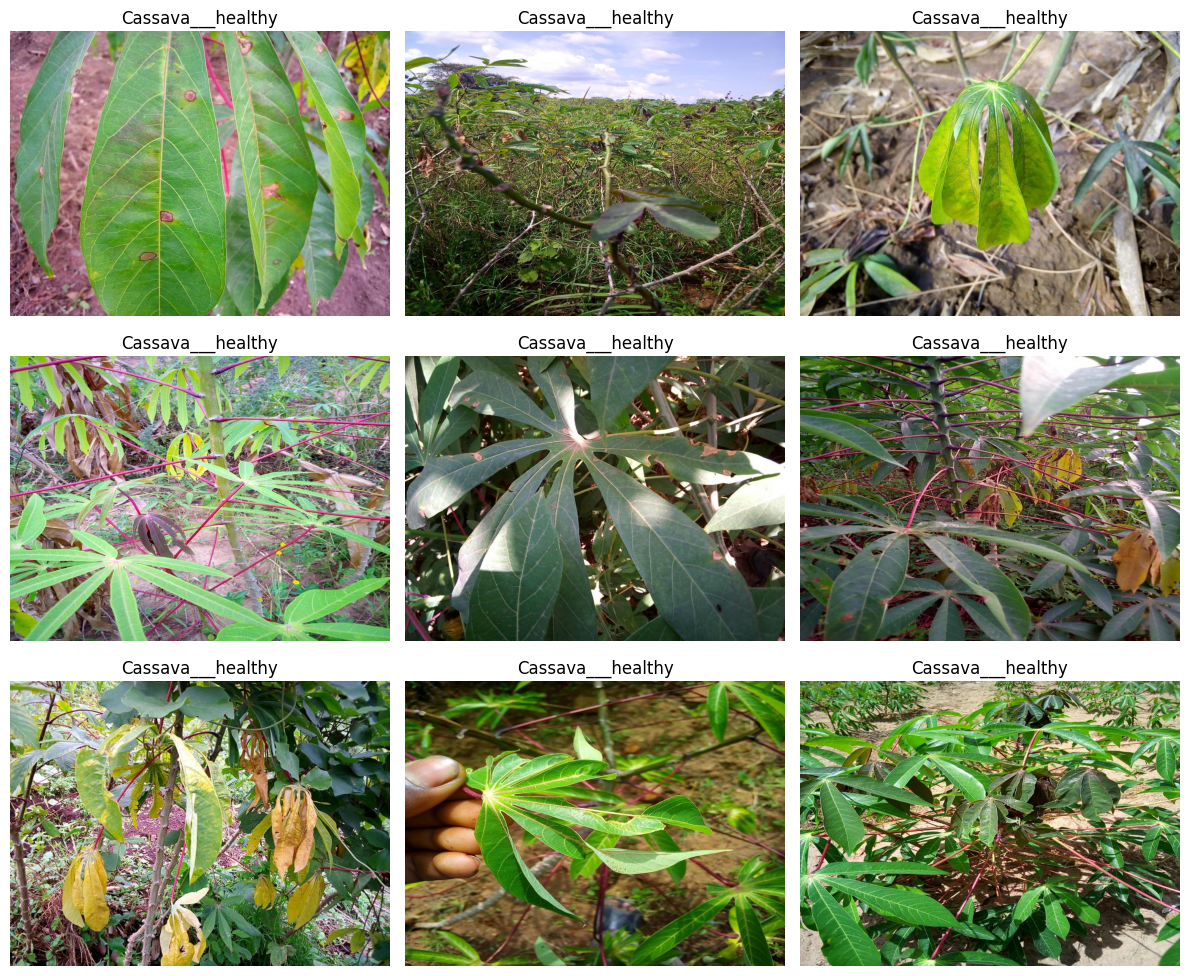

In [24]:
# 4. VISUALIZE SAMPLE IMAGES
# ============================================================

def show_samples(dataframe, num_images=9):
    plt.figure(figsize=(12, 10))

    for i in range(min(num_images, len(dataframe))):
        plt.subplot(3, 3, i + 1)

        img = cv2.imread(dataframe.iloc[i]["filepaths"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.imshow(img)
        plt.title(dataframe.iloc[i]["labels"])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(df)

In [25]:
# 5. TRAIN / VALIDATION / TEST SPLIT
# Example: 70% train, 15% validation, 15% test
# ============================================================

train_df, temp_df = train_test_split(
    df,
    train_size=0.7,
    random_state=SEED,
    stratify=df["labels"]
)

val_df, test_df = train_test_split(
    temp_df,
    train_size=0.5,
    random_state=SEED,
    stratify=temp_df["labels"]
)

print("Train Size:", len(train_df))
print("Validation Size:", len(val_df))
print("Test Size:", len(test_df))

Train Size: 1127
Validation Size: 241
Test Size: 242


In [26]:
# 6. DATA PREPROCESSING + AUGMENTATION
# ============================================================

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_test_gen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
    )

val_data = val_test_gen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = val_test_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepaths",
    y_col="labels",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 1127 validated image filenames belonging to 4 classes.
Found 241 validated image filenames belonging to 4 classes.
Found 242 validated image filenames belonging to 4 classes.


In [27]:
# 7. BUILD MODEL (TRANSFER LEARNING - VGG16)
# ============================================================

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model
base_model.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dropout(0.5)(x)
output = Dense(
    len(train_data.class_indices),
    activation="softmax"
)(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │       100,356 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,815,044 (56.51 MB)

 Trainable params: 100,356 (392.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [28]:
# 8. CALLBACKS
# ============================================================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "best_model.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]


In [ ]:
# 9. TRAINING MODEL
# ============================================================

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    verbose=1
)

Epoch 1/50
17/36 ━━━━━━━━━━━━━━━━━━━━ 12s 642ms/step - accuracy: 0.3019 - loss: 2.0594

In [ ]:
# 10. VISUALIZE LOSS CURVES
# ============================================================

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 11. MODEL EVALUATION
# ============================================================

pred_probs = model.predict(test_data)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_data.classes
class_names = list(test_data.class_indices.keys())

accuracy = accuracy_score(true_classes, pred_classes)
error_rate = 1 - accuracy

print("\nAccuracy:", accuracy)
print("Error Rate:", error_rate)

print("\nClassification Report:\n")
print(classification_report(true_classes, pred_classes, target_names=class_names))


In [ ]:
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# 13. PREDICTION ON SINGLE TEST IMAGE
# ============================================================

sample_index = 5
sample_path = test_df.iloc[sample_index]["filepaths"]

img = tf.keras.preprocessing.image.load_img(sample_path, target_size=IMG_SIZE)
img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis("off")
plt.show()


In [ ]:
model.save("final_corn_leaf_model.h5")
print("\nModel successfully saved.")